Começando pela parte analítica.
No enunciado é dito que 
```math 
y(x,t=0)=\sum_{n=0}^{N-1}a_ny_n(x)
```

com $y_n(x)=\sin(k_nx)$
Para implementar a condição de contorno aberta na ponta direita ($x = L$), precisamos que $\left(\dfrac{\partial{y}}{\partial{x}}\right)_{x=L}=0$. Utilizando a solução para a posição, 
```math
\sum_{n=0}^{N-1}a_nk_n\cos(k_nL)=0
```
Para que esta soma seja nula, precisamos que cada termo se anule individualmente, de sorte que
```math
a_nk_n\cos(k_nL)=0
```
Assumindo que os coeficientes $a_n,k_n\not=0$, então
```math
\cos(k_n L) = 0\Rightarrow k_n L = \pi n + \dfrac{\pi}{2} = \pi\left(n + \dfrac{1}{2}\right), \;\;\; n\in \mathbb{N} \\
\Rightarrow \boxed{k_n = \dfrac{\pi}{2L}(2n + 1)}
```
A frequência angular $\omega_n$ correspondente a um número de onda $k_n$ é dada pela relação
```math
\omega_n = ck_n
```
E a frequência $f_n = \dfrac{\omega_n}{2\pi}$ fica então dada por
```math
\boxed{f_n = \dfrac{c}{4L}(2n+1)}
```
Utilizando os valores do enunciado ($c = 50\text{m/s}$, $L = 1\text{m}$),
```math
\boxed{f_n = 12,5(2n+1)}
```
Desta forma, a frequência fundamental é $f_0 = 12,5\text{Hz}$. Já o terceiro harmônico, $f_2 = 12,5\cdot 5 = 62,5\text{Hz}$.

Para a simulação numérica, é necessário implementar a condição da derivada na ponta. Em termos de uma derivada discreta, precisamos que $\verb|y[-1, n] = y[-2, n]|$, em que $\verb|n|$ é o índice do tempo (lembrando que no python o índice -1 corresponde ao último elemento, o índice -2 ao penúltimo, etc). Assim, a condição da derivada nula na ponta estará satisfeita. Isso está no código a seguir.


In [11]:
import numpy as np
import matplotlib.pyplot as plt


N = 3 #Vamos trabalhar com o terceiro harmonico
an = np.zeros(N)
for ii in range(N):
    if ii == 2:
        an[ii] = 1. #Amplitude 1 no terceiro harmonico
c = 50 #velocidade
L = 1#comprimento
r = 1#Constante que relaciona a discretizacao no espaco e no tempo
dt = 0.0002#Tamanho do passo no tempo. Precisa ser pequeno para ter uma resolucao espacial boa
tf = 0.5#tempo final para a simulacao
dx = c*dt/r #Passo no espaco. para c = 50 e r = 1, dx = 0.01

t = np.arange(0, tf, dt) #Array com os pontos no tempo
x = np.arange(0, 1+dx, dx) #Array com os pontos no espaco
xsize = len(x); tsize = len(t)

def Solve():
    n = np.arange(0, N)

    y0 = np.zeros(xsize)
    for i in range(xsize):
        y0[i] = np.sum(an*np.sin((2*n + 1)*np.pi*x[i]/(2*L))) #Condicao inicial, correspondendo as condicoes de contorno

    y = np.zeros((xsize, tsize))

    y[:, 0] = y0
    y[0, 0] = 0
    y[-1, 0] = y[-2, 0] #Garantindo a derivada nula na ponta, so por precaucao

    #Primeiro passo no tempo
    for j in range(1, xsize-1):
        y[j][1] = 2*y[j][0] - y[j][0] + (r**2)*(y[j+1][0] + y[j-1][0] - 2*y[j][0])
        y[-1, 1] = y[-2, 1]

    #Iteracao para resolver a equacao em termos de posicao e tempo
    for i in range(1, tsize-1):
        for j in range(1, xsize-1):
            y[-1, i] = y[-2, i] #Novamente, garantindo a restricao da derivada na ponta (por precaucao)
            y[j][i+1] = 2*y[j][i]-y[j][i-1] + (r**2)*(y[j+1][i] + y[j-1][i] - 2*y[j][i]) #Equacao de onda discretizada
            y[-1, i+1] = y[-2, i+1] #E garantindo denovo a restricao

    return y, x, t

Ywave, xvec, tvec = Solve()
for ii in range(-10,0):
     print("{:10.6e}".format(Ywave[xsize//2 + ii, -1])) #print dos resultados

3.178636e-02
9.516312e-02
1.579532e-01
2.197694e-01
2.802306e-01
3.389642e-01
3.956079e-01
4.498125e-01
5.012440e-01
5.495850e-01


In [12]:
def FT(t, y):
    im = 0+1.0j

    fk = np.zeros(tsize)

    ft = np.zeros((tsize), dtype = complex)
    for i in range(tsize):
        fk[i] = i/(tsize*dt)
        for j in range(tsize):
            ft[i] += y[j]*np.exp(2*np.pi*im*i*j/tsize)
    return fk, ft

Ywave, xvec, tvec = Solve()

ind = round(0.5/dx)
fk, ft = FT(tvec, Ywave[ind])

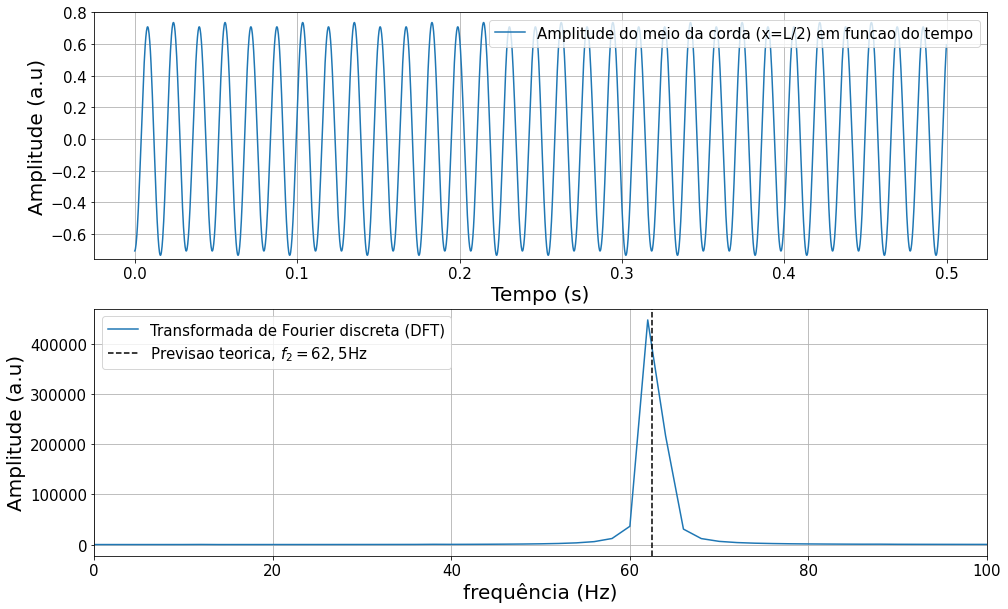

In [24]:
fig, ax = plt.subplots(2, 1, figsize = (16, 10))

ax[0].plot(tvec, Ywave[ind], label = r'Amplitude do meio da corda (x=L/2) em funcao do tempo')
ax[0].set_ylim(-0.76, 0.8)

ax[0].set_xlabel(r'Tempo (s)', fontsize = 20)
ax[0].set_ylabel(r'Amplitude (a.u)', fontsize = 20)
ax[0].tick_params(labelsize = 15)

ax[0].legend(loc = 'upper right', fontsize = 15)
ax[0].grid(visible = True)


ax[1].plot(fk, np.abs(ft)**2, label = r'Transformada de Fourier discreta (DFT)')
ax[1].axvline(5*12.5, c = 'black', label = r'Previsao teorica, $f_2 = 62,5$Hz', linestyle = 'dashed')
ax[1].set_xlim(0, 100)

ax[1].set_xlabel(r'frequência (Hz)', fontsize = 20)
ax[1].set_ylabel(r'Amplitude (a.u)', fontsize = 20)
ax[1].tick_params(labelsize = 15)

ax[1].legend(fontsize = 15)
ax[1].grid(visible = True)

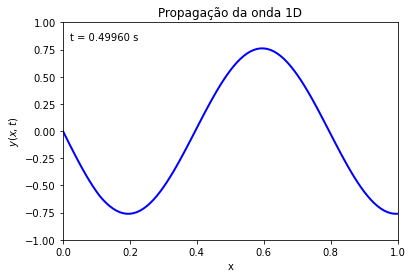

In [30]:
#Animacao da onda

from matplotlib import pyplot
from matplotlib import animation
# número de frames: amostramos a solução para não animar TODOS os passos
# de tempo (que podem ser milhares) e a animação ficar rápida demais/lenta
n_frames_desejado = 900
passo = max(1, tsize // n_frames_desejado)
indices_frames = range(0, tsize, passo)
fig_anim, ax_anim = pyplot.subplots()
ax_anim.set_xlim(0, L)
ax_anim.set_ylim(-1.0, 1.)
ax_anim.set_xlabel('x')
ax_anim.set_ylabel(r'$y(x,t)$')
ax_anim.set_title('Propagação da onda 1D')
linha, = ax_anim.plot([], [], 'b-', lw=2)
texto_tempo = ax_anim.text(0.02, 0.92, '', transform=ax_anim.transAxes)
def inicializar():
        linha.set_data([], [])
        texto_tempo.set_text('')
        return linha, texto_tempo

def atualizar(it):
        linha.set_data(xvec, Ywave[:, it])
        texto_tempo.set_text('t = {:.5f} s'.format(tvec[it]))
        return linha, texto_tempo


anim = animation.FuncAnimation(
        fig_anim, atualizar, frames=indices_frames,
        init_func=inicializar, blit=True, interval=30
    )

# Para salvar a animação em arquivo (descomente a opção desejada):
#
# GIF (requer o pacote 'pillow' instalado: pip install pillow)
anim.save('/home/luan/Documentos/Atividades_metodos_comp/Metodos/Atv2/pacote_animacao.gif', writer='pillow', fps=30)
#
# MP4 (requer o ffmpeg instalado no sistema)
# anim.save('onda_animacao.mp4', writer='ffmpeg', fps=30)